# M2 — Fitter Dispatch and Geometry Threading

This notebook is the explainer for **Milestone M2** of the `rob_rt` integration
(`claude_prompts/RT/rob_rt_prompt_3.md`): all four `rt_dict['rt_backend']`
values are now selectable end-to-end from the fitters. `log_prob` and
`chisq_fit.fit_func` carry the two-line dispatch, the observation tuple grew an
optional trailing `geom` element, and `validate_rt_dict` /
`robust_domain_check` run once at fit setup. M1 (`rob_rt_coding_2.ipynb`)
built the forward adapter; M2 wired it into the fitting machinery.

Four sections, matching what M2's task 4 promises:

1. **One L23 spectrum, four backends, end-to-end** — the same real spectrum
   fit through `fit_one` under `gordon`, `robust_ztt`, `robust_hybrid`, and
   `robust_baseline` (small nsteps), with finite chains and a side-by-side
   posterior summary.
2. **The nadir fallback** — `ObsGeometry(theta_s=30.)` (implicit nadir) and
   `ObsGeometry(30., 0., 0.)` (explicit nadir) give *identical* `log_prob`
   and Rrs, shown numerically rather than asserted.
3. **Non-nadir geometry is not a no-op** — `ObsGeometry(30., theta_v=40.,
   dphi=90.)` visibly changes Rrs under `robust_ztt`, on identical IOPs.
4. **The raised errors, as a user sees them** — the missing-`geom` setup
   error (naming `theta_s`) and the `robust_hybrid` out-of-range-grid error,
   each triggered live through a fitter and printed verbatim.

## Setup: one real L23 spectrum

Same recipe as M1's notebook and the test fixtures: `prep_one_l23` loads L23
spectrum idx=170 interpolated to the PACE grid, builds the `ExpBricaud`+`Pow`
model pair, and produces an `init_guess` parameter vector from the spectrum's
true `a_nw`/`bb_nw`. Requires the L23 store (`$OS_COLOR`).

Two M2-specific setup choices:

- **Small chains** (`nsteps=200`, `nburn=50`, 16 walkers, seeded): these are
  the Gate's *smoke* fits — enough sampling to show every backend runs
  end-to-end with finite, sensibly-centered chains, not converged posteriors.
- **`theta_s=30°`**: the L23 loader carries no per-spectrum solar geometry,
  so we adopt the same fixed 30° convention as M1's notebook and the M2 test
  suite. `Bp_value=0.014` sits inside the hybrid emulator's trained domain
  at this geometry (M1 §4 stepped outside it deliberately).

The `pdict['Chl']`/`pdict['Y']` indexing below mirrors `l23.fit_one`'s own
single-spectrum convention (`fit_one` looks both up by the tuple's `idx`).

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt

from bing.parameters import standard
from bing.fitting import l23 as fit_l23
from bing.fitting import inference as bing_inf
from bing.fitting import chisq_fit
from bing.models import utils as model_utils
from bing.rt import defs as rt_defs
from bing.rt.geometry import ObsGeometry
from bing import evaluate

# Real L23 reference spectrum: idx=170, PACE grid (same as M1 and the tests).
NSTEPS, NBURN = 200, 50
p = standard.expb_pow(satellite='PACE', add_noise=False,
                      variable_Gordon=False, include_Raman=False,
                      include_Chl_fl=False, nsteps=NSTEPS, nburn=NBURN)
prep = fit_l23.prep_one_l23(p, idx=170)
models = prep['models']
Rrs = prep['model_Rrs']
varRrs = prep['model_varRrs']
p0 = prep['p0']
idx = 170

# Chl/Y lookup arrays, indexed by the tuple's idx (l23.fit_one's convention)
pdict = prep['pdict']
pdict['Chl'] = np.zeros(idx + 1); pdict['Chl'][idx] = prep['odict']['Chl']
pdict['Y'] = np.zeros(idx + 1);   pdict['Y'][idx] = prep['odict']['Y']

# M0's configuration surface: the rt_dict and the fixed per-pixel geometry
base_rt = rt_defs.rt_dict_from_p(p)   # legacy p -> 'gordon' defaults
base_rt['Bp_value'] = 0.014           # inside the emulator's trained domain
geom = ObsGeometry(theta_s=30.)       # required for robust backends

pnames = models[0].pnames + models[1].pnames
wave = np.asarray(models[0].wave)
print(f"wave grid : {wave.size} bands, {wave.min():.0f}-{wave.max():.0f} nm (PACE)")
print(f"L23 truth : Chl = {float(pdict['Chl'][idx]):.4f} mg/m3, Y = {float(pdict['Y'][idx]):.4f} (idx=170)")
print(f"p0 ({pnames}) = {np.round(p0, 4)}")
print(f"MCMC      : nsteps={NSTEPS}, nburn={NBURN}, nwalkers={pdict['nwalkers']}")
print(f"geom      : {geom}")

wave grid : 61 bands, 400-700 nm (PACE)
L23 truth : Chl = 0.1306 mg/m3, Y = 2.1521 (idx=170)
p0 (['Adg', 'Sdg', 'Aph', 'Bnw', 'beta']) = [-1.8799  0.017  -1.8799 -3.4926  1.    ]
MCMC      : nsteps=200, nburn=50, nwalkers=16
geom      : ObsGeometry(theta_s=30.0, theta_v=0.0, dphi=0.0, wind=None)


## 1. One spectrum, four backends, end-to-end through `fit_one`

The observation tuple is now `(Rrs, varRrs, p0, idx[, geom])`. The Gordon fit
below deliberately uses the **legacy 4-tuple** — exactly what every existing
call site passes today, exercising the default-backend path unchanged — while
the three robust backends use the 5-tuple with the `ObsGeometry`. Each fit is
re-seeded identically, so the walker initialization and proposal sequence are
the same across backends; any difference in the chains comes from the forward
physics alone.

Along the way, `fit_one` is silently doing M2's new setup work on every robust
fit: `validate_rt_dict` (backend name, geometry, hybrid grid), then
`robust_domain_check` on `p0` before sampling and on the posterior median
after — all outside emcee's jitted hot loop.

In [2]:
BACKENDS = ['gordon', 'robust_ztt', 'robust_hybrid', 'robust_baseline']

all_chains = {}
for backend in BACKENDS:
    rt_dict = dict(base_rt, rt_backend=backend)
    if backend == 'gordon':
        items = (Rrs, varRrs, p0, idx)          # legacy 4-tuple, no geom
    else:
        items = (Rrs, varRrs, p0, idx, geom)    # 5-tuple with ObsGeometry
    np.random.seed(2026)                        # identical walkers/proposals
    chains, _ = bing_inf.fit_one(items, models=models, pdict=pdict,
                                 chains_only=True, rt_dict=rt_dict)
    all_chains[backend] = chains

for backend, chains in all_chains.items():
    print(f"{backend:16s} chains {chains.shape}  "
          f"finite: {np.all(np.isfinite(chains))}")

idx=170
Running burn-in


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:00<00:00, 1829.37it/s]

Running full model


  0%|          | 0/200 [00:00<?, ?it/s]

...

 22%|██▎       | 45/200 [00:00<00:00, 446.03it/s]

 48%|████▊     | 97/200 [00:00<00:00, 486.57it/s]

 76%|███████▌  | 151/200 [00:00<00:00, 510.72it/s]

100%|██████████| 200/200 [00:00<00:00, 509.81it/s]

gordon           chains (200, 16, 5)  finite: True
robust_ztt       chains (200, 16, 5)  finite: True
robust_hybrid    chains (200, 16, 5)  finite: True
robust_baseline  chains (200, 16, 5)  finite: True


In [3]:
# Posterior medians, side by side.  Small-nsteps smoke fits -- centered
# sensibly near p0, not converged posteriors.
flat = {b: c.reshape(-1, c.shape[-1]) for b, c in all_chains.items()}

hdr = f"{'param':>8s}" + "".join(f"{b:>17s}" for b in BACKENDS)
print(hdr)
print("-" * len(hdr))
for j, name in enumerate(pnames):
    row = f"{name:>8s}"
    for b in BACKENDS:
        row += f"{np.median(flat[b][:, j]):>17.4f}"
    print(row)

# robust_baseline is robust's Gordon-compatible refit: within float32 of the
# Gordon path (M1 parity, rtol <= 1e-5).  With identical seeds its accept/
# reject sequence tracks Gordon's almost perfectly:
dmed = np.abs(np.median(flat['robust_baseline'], axis=0)
              - np.median(flat['gordon'], axis=0))
print(f"\nmax |median(robust_baseline) - median(gordon)| = {dmed.max():.2e}")

   param           gordon       robust_ztt    robust_hybrid  robust_baseline
----------------------------------------------------------------------------
     Adg          -1.6826          -1.6652          -1.6751          -1.6826
     Sdg           0.0167           0.0171           0.0154           0.0167
     Aph          -2.0233          -1.9981          -2.0423          -2.0233
     Bnw          -3.5511          -3.6804          -3.6753          -3.5511
    beta           1.1287           0.9039           1.2125           1.1287

max |median(robust_baseline) - median(gordon)| = 0.00e+00


Every backend runs end-to-end from the same call signature, returns the same
`(nsteps, nwalkers, nparam)` chain shape, and stays finite throughout. The
medians tell the physics story M1 measured: the real robust backends
(`robust_ztt`, `robust_hybrid`) predict Rrs a few percent **above** Gordon on
this spectrum (M1: +0.3% to +7.4%, median +4.5%), so their posteriors center
on genuinely different parameter values — visibly so in `Bnw` and `beta` —
while `robust_baseline`, robust's Gordon-compatible refit, reproduces the
Gordon chains almost exactly (same seed, forward models within float32 of
each other, hence a near-identical accept/reject sequence).

> These are the notebook's *demonstrations* of the Gate's end-to-end smoke
> fits; automated pytest coverage of Gate item 1 (all four backends through
> both fitters on an L23 spectrum) does not exist yet — see Q5 in the prompt
> doc.

## 2. The nadir fallback: implicit vs explicit

Design §3.2: when only a solar zenith is known, `theta_v`/`dphi` default to
nadir viewing — `ObsGeometry(theta_s=30.)` must mean *exactly*
`ObsGeometry(30., 0., 0.)`, not approximately. Shown here on `log_prob` (the
MCMC objective itself) and on the full Rrs spectrum, at the L23 initial
guess under `robust_ztt`.

In [4]:
rt_ztt = dict(base_rt, rt_backend='robust_ztt')
geom_implicit = ObsGeometry(theta_s=30.)     # nadir by default
geom_explicit = ObsGeometry(30., 0., 0.)     # nadir spelled out

lp_implicit = bing_inf.log_prob(p0, models, Rrs, varRrs, rt_ztt,
                                geom=geom_implicit)
lp_explicit = bing_inf.log_prob(p0, models, Rrs, varRrs, rt_ztt,
                                geom=geom_explicit)
print(f"log_prob, implicit nadir : {lp_implicit!r}")
print(f"log_prob, explicit nadir : {lp_explicit!r}")
print(f"difference               : {lp_implicit - lp_explicit!r}")
print(f"identical (==)           : {lp_implicit == lp_explicit}")

# The full Rrs spectra behind those log_probs, compared elementwise
nap = models[0].nparam
Rrs_implicit = evaluate.calc_Rrs_from_models_robust(
    models[0], p0[:nap], models[1], p0[nap:], rt_ztt, geom=geom_implicit)
Rrs_explicit = evaluate.calc_Rrs_from_models_robust(
    models[0], p0[:nap], models[1], p0[nap:], rt_ztt, geom=geom_explicit)
print(f"max |Rrs_implicit - Rrs_explicit| : "
      f"{np.max(np.abs(Rrs_implicit - Rrs_explicit))!r}  (all {Rrs_implicit.size} bands)")

log_prob, implicit nadir : np.float64(-27.05867534787494)
log_prob, explicit nadir : np.float64(-27.05867534787494)
difference               : np.float64(0.0)
identical (==)           : True
max |Rrs_implicit - Rrs_explicit| : np.float32(0.0)  (all 61 bands)


Zero — not small, zero. Both `ObsGeometry` instances map onto the same
`robust.rt.types.Geometry` values, feed the same jitted forward closure, and
produce bitwise-identical Rrs and log-probability. The nadir fallback is a
pure spelling convenience.

## 3. Non-nadir geometry is not a no-op

The same IOPs (the L23 initial guess), the same `robust_ztt` backend, the same
`theta_s=30°` sun — but the sensor moved off nadir to `theta_v=40°`,
`dphi=90°`. Under the Gordon backend this geometry would be silently ignored;
under `robust.rt` it changes the water-leaving radiance geometry and therefore
Rrs itself.

relative change, off-nadir vs nadir:
  median : -10.28%
  range  : [-11.54%, -8.19%]
  max |dRrs| : 8.986e-04 sr^-1


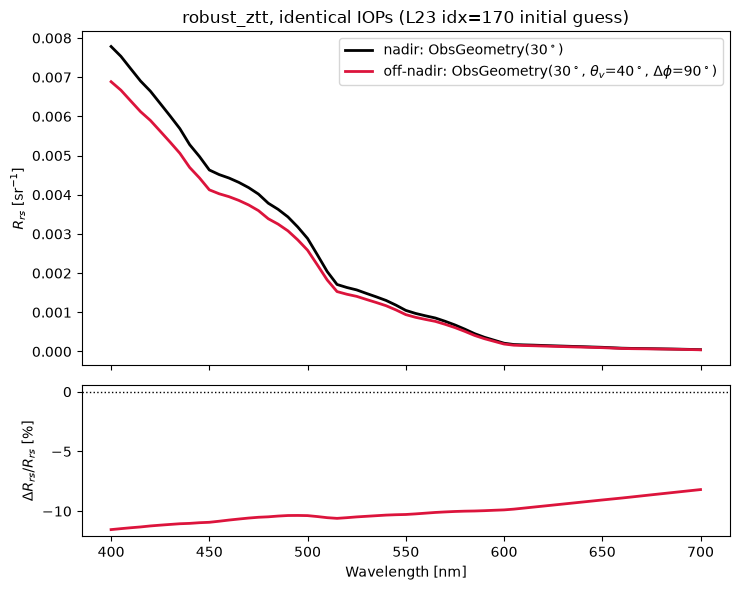

In [5]:
geom_offnadir = ObsGeometry(30., theta_v=40., dphi=90.)

Rrs_nadir = np.squeeze(Rrs_implicit)
Rrs_offnadir = np.squeeze(evaluate.calc_Rrs_from_models_robust(
    models[0], p0[:nap], models[1], p0[nap:], rt_ztt, geom=geom_offnadir))

rel = (Rrs_offnadir - Rrs_nadir) / Rrs_nadir
print(f"relative change, off-nadir vs nadir:")
print(f"  median : {np.median(rel)*100:+.2f}%")
print(f"  range  : [{rel.min()*100:+.2f}%, {rel.max()*100:+.2f}%]")
print(f"  max |dRrs| : {np.max(np.abs(Rrs_offnadir - Rrs_nadir)):.3e} sr^-1")

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(7.5, 6.), sharex=True,
                               height_ratios=[2.2, 1.])
ax0.plot(wave, Rrs_nadir, 'k-', lw=2,
         label=r'nadir: ObsGeometry(30$^\circ$)')
ax0.plot(wave, Rrs_offnadir, '-', color='crimson', lw=2,
         label=r'off-nadir: ObsGeometry(30$^\circ$, $\theta_v$=40$^\circ$, $\Delta\phi$=90$^\circ$)')
ax0.set_ylabel(r'$R_{rs}$ [sr$^{-1}$]')
ax0.legend(fontsize=10)
ax0.set_title('robust_ztt, identical IOPs (L23 idx=170 initial guess)')
ax1.plot(wave, rel * 100, '-', color='crimson', lw=2)
ax1.axhline(0., color='k', ls=':', lw=1)
ax1.set_xlabel('Wavelength [nm]')
ax1.set_ylabel(r'$\Delta R_{rs}/R_{rs}$ [%]')
plt.tight_layout()
plt.show()

An ~8–12% suppression of Rrs across the spectrum — several times the 2%
noise floor used throughout this work, and wavelength-dependent. This is exactly why geometry rides
the observation tuple per pixel instead of being baked into `rt_dict`: it is
real, fixed, per-scene physics (design Q3/Q11/Q14 — never a fit parameter),
and the robust backends actually respond to it.

## 4. The raised errors, as a user sees them

M2 task 3 moved configuration failure to **fit setup** — once per fit, before
any sampling or optimizer work. Two errors a user will actually meet, each
triggered through a real fitter call and printed verbatim.

**(a) A robust backend without geometry.** A legacy 4-tuple is still perfectly
valid for Gordon fits (section 1 ran one), but a robust backend cannot invent
a solar zenith — `theta_s` is never silently defaulted (CQ4).

In [6]:
try:
    bing_inf.fit_one((Rrs, varRrs, p0, idx),          # legacy 4-tuple: no geom
                     models=models, pdict=pdict, chains_only=True,
                     rt_dict=dict(base_rt, rt_backend='robust_ztt'))
except ValueError as err:
    print(f"ValueError:\n  {err}")

ValueError:
  rt_dict['rt_backend']='robust_ztt' requires geometry -- pass an ObsGeometry via geom= (theta_s is never silently defaulted; claude_prompts/rob_rt.md Q&A/Coding item 4)


**(b) A `robust_hybrid` fit on a wavelength grid outside the emulator's
training range.** The hybrid emulator was trained on [350, 750] nm; a grid
reaching 760 nm is refused at setup. Shown through `chisq_fit.fit` — both
fitters share the same `validate_rt_dict` gate.

In [7]:
wide_wave = np.arange(400., 765., 5.)                  # 400-760 nm inclusive
wide_models = model_utils.init(['ExpBricaud', 'Pow'], wide_wave)

try:
    chisq_fit.fit((Rrs, varRrs, p0, idx, geom),        # geom present and legal
                  wide_models,
                  dict(base_rt, rt_backend='robust_hybrid'))
except ValueError as err:
    print(f"ValueError:\n  {err}")

ValueError:
  rt_dict['rt_backend']='robust_hybrid' requires all wavelengths within [350.0, 750.0] nm (the emulator's training range); got range [400.0, 760.0]


Both errors fire before any MCMC or optimizer work (the test suite pins this
with sentinel monkeypatches on `run_emcee`/`curve_fit`), and both messages say
what to do about it, not just what went wrong.

## What M2 established

- **One call signature, four backends.** `fit_one` and `chisq_fit.fit` accept
  `(Rrs, varRrs, p0, idx[, geom])` and dispatch on
  `rt_dict.get('rt_backend', 'gordon')`; legacy 4-tuple Gordon calls are
  byte-for-byte untouched (section 1's Gordon fit *is* one).
- **Geometry threads by value, never as a dimension.** The `ObsGeometry`
  rides emcee's positional `args` into `log_prob` (and `curve_fit`'s
  `partial` into `fit_func`); the chain width stays `nparam`. Implicit and
  explicit nadir are bitwise identical (section 2: difference exactly 0.0),
  and non-nadir geometry genuinely moves Rrs (section 3: ~−10% at
  `theta_v=40°`, `dphi=90°`).
- **Configuration fails at setup, loudly.** `validate_rt_dict` runs once per
  fit in both fitters; `robust_domain_check` brackets the sampling (p0 and
  posterior median) for robust backends only.

## What's next

**M2 task 5**: update `rob_rt_prompt_4.md` (M3: `B_p` as an optional free
MCMC parameter) with what M2 established — the fitter signatures as they now
stand and the smoke-fit numbers above (16 walkers, seconds-scale runtimes,
one-time JIT compile per robust backend/grid).